# Wind Reliability Analysis (January 2024)

This notebook estimates how much UK wind generation can be **reliably expected** to be available for demand support.

## Objective
- Analyze historical actual wind generation (January 2024).
- Quantify stability and low-output risk.
- Recommend a conservative MW value with evidence and confidence interval.

In [1]:
import warnings
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

API_BASE_URL = "http://localhost:8010"
START_ISO = "2024-01-01T00:00:00Z"
END_ISO = "2024-01-31T23:30:00Z"

print("Config loaded.")

Config loaded.


In [2]:
def fetch_actual_series(start_iso: str, end_iso: str, api_base_url: str = API_BASE_URL) -> pd.DataFrame:
    """Fetch actual generation via merged endpoint, then keep actual column."""
    response = requests.get(
        f"{api_base_url}/api/forecasts",
        params={"start": start_iso, "end": end_iso, "horizon": 4},
        timeout=180,
    )
    response.raise_for_status()

    points = response.json().get("points", [])
    if not points:
        return pd.DataFrame()

    df = pd.DataFrame(points)
    df["target_time"] = pd.to_datetime(df["target_time"], utc=True)
    df = df.dropna(subset=["actual_generation_mw"]).copy()
    df = df[["target_time", "actual_generation_mw"]].sort_values("target_time")
    df["hour_utc"] = df["target_time"].dt.hour
    df["date_utc"] = df["target_time"].dt.date
    return df


actual_df = fetch_actual_series(START_ISO, END_ISO)
print(f"Actual points: {len(actual_df):,}")
actual_df.head()

Actual points: 1,488


,target_time,actual_generation_mw,hour_utc,date_utc
0,2024-01-01 00:00:00+00:00,10402.0,0,2024-01-01
1,2024-01-01 00:30:00+00:00,10845.0,0,2024-01-01
2,2024-01-01 01:00:00+00:00,11218.0,1,2024-01-01
3,2024-01-01 01:30:00+00:00,11223.0,1,2024-01-01
4,2024-01-01 02:00:00+00:00,11234.0,2,2024-01-01


In [3]:
summary_stats = pd.Series(
    {
        "mean_mw": actual_df["actual_generation_mw"].mean(),
        "median_mw": actual_df["actual_generation_mw"].median(),
        "std_mw": actual_df["actual_generation_mw"].std(),
        "p01_mw": actual_df["actual_generation_mw"].quantile(0.01),
        "p05_mw": actual_df["actual_generation_mw"].quantile(0.05),
        "p10_mw": actual_df["actual_generation_mw"].quantile(0.10),
        "p25_mw": actual_df["actual_generation_mw"].quantile(0.25),
    }
).round(2)

summary_stats

mean_mw      9848.73
median_mw    9863.50
std_mw       3676.02
p01_mw       3233.58
p05_mw       4301.10
p10_mw       5087.90
p25_mw       6732.50
dtype: float64

In [4]:
# Availability curve: probability of meeting or exceeding a threshold
thresholds = np.arange(0, int(actual_df["actual_generation_mw"].max()) + 500, 250)
availability = pd.DataFrame({"threshold_mw": thresholds})
availability["prob_meet_or_exceed"] = availability["threshold_mw"].apply(
    lambda t: (actual_df["actual_generation_mw"] >= t).mean()
)

availability.head(10)

,threshold_mw,prob_meet_or_exceed
0,0,1.000000
1,250,0.998656
2,500,0.998656
3,750,0.998656
4,1000,0.998656
5,1250,0.998656
6,1500,0.998656
7,1750,0.998656
8,2000,0.998656
9,2250,0.998656


In [5]:
# Bootstrap CI for conservative reliability estimate using the 10th percentile
rng = np.random.default_rng(42)
boot_iterations = 2000
sample = actual_df["actual_generation_mw"].to_numpy()

boot_p10 = np.empty(boot_iterations)
for i in range(boot_iterations):
    boot_sample = rng.choice(sample, size=sample.shape[0], replace=True)
    boot_p10[i] = np.quantile(boot_sample, 0.10)

p10_point = float(np.quantile(sample, 0.10))
p10_ci_low = float(np.quantile(boot_p10, 0.025))
p10_ci_high = float(np.quantile(boot_p10, 0.975))

recommendation_mw = round(p10_point, -1)  # Round to practical nearest 10 MW

print(f"P10 point estimate: {p10_point:,.1f} MW")
print(f"95% bootstrap CI for P10: [{p10_ci_low:,.1f}, {p10_ci_high:,.1f}] MW")
print(f"Recommended reliable wind availability: {recommendation_mw:,.0f} MW")

P10 point estimate: 5,087.9 MW
95% bootstrap CI for P10: [4,818.1, 5,339.9] MW
Recommended reliable wind availability: 5,090 MW


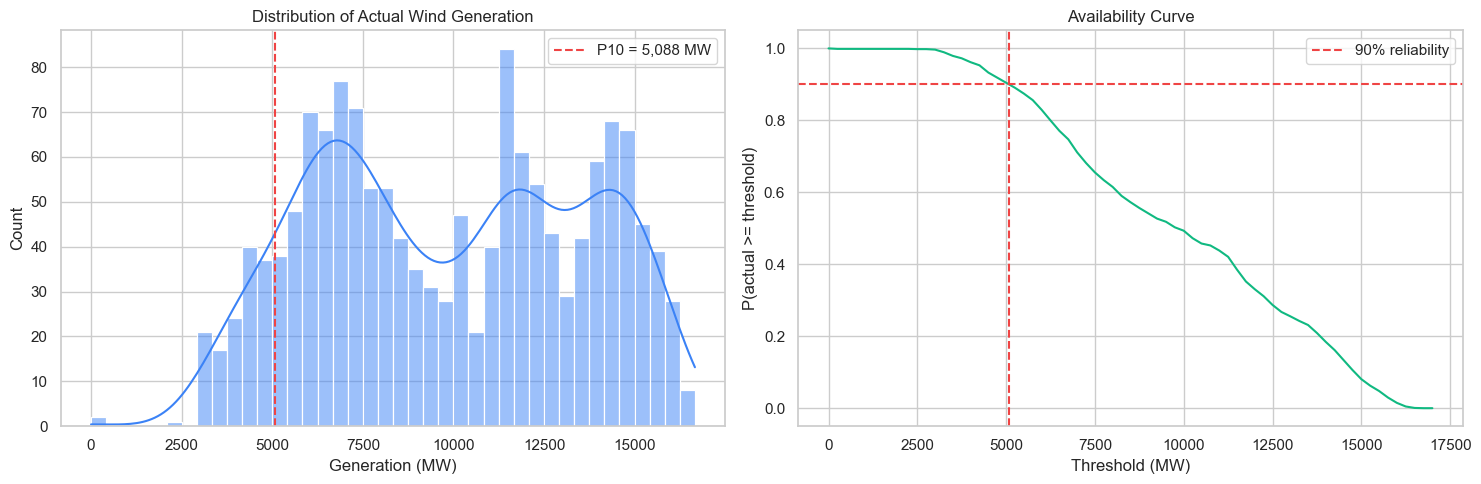

,hour_utc,mean_mw,median_mw,p10_mw
0,0,9638.048387,9607.0,5805.1
1,1,9599.467742,9409.0,5995.0
2,2,9482.241935,8701.5,5824.3
3,3,9391.209677,8303.5,5570.8
4,4,9264.209677,8797.5,5496.4
5,5,9338.080645,9473.5,5307.9
6,6,9486.645161,9356.5,5713.0
7,7,9642.322581,8746.0,5304.7
8,8,9743.387097,9055.0,5396.0
9,9,9804.225806,9197.0,5126.1


In [6]:
hourly_profile = (
    actual_df.groupby("hour_utc", as_index=False)
    .agg(
        mean_mw=("actual_generation_mw", "mean"),
        median_mw=("actual_generation_mw", "median"),
        p10_mw=("actual_generation_mw", lambda s: s.quantile(0.10)),
    )
    .sort_values("hour_utc")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(actual_df["actual_generation_mw"], kde=True, bins=40, color="#3b82f6", ax=axes[0])
axes[0].axvline(p10_point, color="#ef4444", linestyle="--", label=f"P10 = {p10_point:,.0f} MW")
axes[0].set_title("Distribution of Actual Wind Generation")
axes[0].set_xlabel("Generation (MW)")
axes[0].legend()

sns.lineplot(data=availability, x="threshold_mw", y="prob_meet_or_exceed", ax=axes[1], color="#10b981")
axes[1].axhline(0.90, color="#ef4444", linestyle="--", label="90% reliability")
axes[1].axvline(p10_point, color="#ef4444", linestyle="--")
axes[1].set_title("Availability Curve")
axes[1].set_xlabel("Threshold (MW)")
axes[1].set_ylabel("P(actual >= threshold)")
axes[1].legend()

plt.tight_layout()
plt.show()

hourly_profile

## Recommendation and Reasoning (Completed)

### Reliability definition

For this notebook, "reliably available" means generation that is met or exceeded in **90% of half-hour intervals** (empirical **P10**).

### Key results (January 2024)

- Mean actual generation: **9848.73 MW**
- Median actual generation: **9863.50 MW**
- P10 actual generation: **5087.90 MW**
- 95% bootstrap CI for P10: **[4818.10, 5339.90] MW**

### Recommendation

A practical planning recommendation is **5090 MW** of reliably available wind generation (rounded P10).

### Why this is a reasonable conservative number

- It targets a 90% availability standard, which is conservative for firm planning compared to mean/median values.
- The bootstrap CI is relatively tight around ~5.1 GW, supporting stability of this estimate within January data.
- Intraday P10 varies by hour (lowest around **3476.4 MW** at hour 11 UTC and highest around **5995.0 MW** at hour 1 UTC), so operational schedules should still consider time-of-day variation.

### Caveats

- This estimate uses **January 2024 only**; seasonality is not captured.
- Weather regimes in other months can materially change reliability percentiles.
- Grid operations should pair this value with reserve, storage, and interconnection strategy rather than treating it as a hard guarantee.